In [1]:
# Setup and Imports
from pathlib import Path
import os, sys

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

from fmu2ml.data.processors import (
    NormalizationHandler,
    DatacenterCoolingDataset,
    SingleChunkSplitDataset,
    create_data_loaders,
    DataValidator,
    ValidationLevel,
    PhysicsValidator
)
from fmu2ml.config import ModelConfig, TrainingConfig
from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline

print("✓ Imports complete")

✓ Imports complete


In [2]:
# Configuration
SYSTEM_NAME = 'summit'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()

# Data paths
DATA_PATH = '../summit/data/systematic/'
CHUNK_TO_TEST = 0
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/systematic/data_processing_tests'

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# System parameters
NUM_CDUS = config['NUM_CDUS']
SEQUENCE_LENGTH = 20
BATCH_SIZE = 64
NUM_WORKERS = 48

print(f"System: {SYSTEM_NAME}")
print(f"Number of CDUs: {NUM_CDUS}")
print(f"Data path: {DATA_PATH}")
print(f"Test chunk: {CHUNK_TO_TEST}")
print(f"Sequence length: {SEQUENCE_LENGTH}")
print(f"Output directory: {OUTPUT_DIR}")

System: summit
Number of CDUs: 257
Data path: ../summit/data/systematic/
Test chunk: 0
Sequence length: 20
Output directory: ../results/summit/systematic/data_processing_tests


In [4]:
# Load Raw Data for Inspection
print("="*80)
print("LOADING RAW DATA")
print("="*80)

chunk_path = Path(DATA_PATH) #/ f"chunk_{CHUNK_TO_TEST}"
parquet_files = list(chunk_path.glob("*_output_*.parquet"))

if not parquet_files:
    parquet_files = list(chunk_path.glob("*.parquet"))

if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {chunk_path}")

parquet_file = parquet_files[0]
print(f"Loading: {parquet_file}")

df = pd.read_parquet(parquet_file)

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"Samples: {len(df)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

# Display first few rows
display(Markdown("### First 5 rows"))
display(df.head())

LOADING RAW DATA
Loading: ../summit/data/systematic/systematic_fmu_output_11hrs.parquet

Dataset shape: (42922, 6430)
Columns: 6430
Samples: 42922
Memory usage: 2207.91 MB


### First 5 rows

,simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_7_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_9_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_10_cabinet_1_sources_Q_flow_total,...,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_prim_s,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_prim_s_psig,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_prim_r,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_prim_r_psig,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_sec_s,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_sec_s_psig,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_sec_r,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_sec_r_psig,simulator[1].datacenter[1].computeBlock[257].cabinet[1].summary.htc,pue
0,22167.118701,19076.011734,37246.434571,25035.180613,38287.897553,27761.758785,31497.847103,26865.519922,18021.452177,28221.602459,...,550243.096751,65.302240,537310.469638,63.426521,304861.044441,29.712582,104861.045251,0.705035,50.0,1.132631
1,22166.001086,19188.541331,37258.402947,25035.180613,38287.897553,27761.758785,31479.975643,26839.406462,18021.452177,28240.647649,...,550246.359389,65.302713,537313.750965,63.426997,304861.140733,29.712596,104861.141543,0.705049,50.0,1.132642
2,22164.909776,19332.674645,37270.354100,25035.180613,38287.897553,27761.758785,31462.103642,26813.352072,18021.452177,28259.712583,...,550249.621496,65.303187,537317.031759,63.427473,304861.248999,29.712612,104861.249808,0.705065,50.0,1.132656
3,22163.844773,19508.003115,37282.287992,25035.180613,38287.897553,27761.758785,31444.231135,26787.357069,18021.452177,28278.797157,...,550252.883059,65.303660,537320.312006,63.427949,304861.250673,29.712612,104861.251482,0.705065,50.0,1.132648
4,22162.806080,19714.029753,37294.204588,25035.180613,38287.897553,27761.758785,31426.358158,26761.421769,18021.452177,28297.901268,...,550256.144082,65.304133,537323.591709,63.428424,304861.189073,29.712603,104861.189883,0.705056,50.0,1.132667


In [5]:
# Inspect Column Structure
print("="*80)
print("COLUMN STRUCTURE ANALYSIS")
print("="*80)

# Categorize columns
input_cols = []
output_cols = []
other_cols = []

for col in df.columns:
    if 'sources_Q_flow_total' in col or 'sources_T_Air' in col or 'sources_T_ext' in col:
        input_cols.append(col)
    elif 'cdu[1].summary' in col or 'datacenter[1].summary' in col or 'htc' in col or col == 'pue':
        output_cols.append(col)
    else:
        other_cols.append(col)

print(f"\nInput columns: {len(input_cols)}")
print(f"Output columns: {len(output_cols)}")
print(f"Other columns: {len(other_cols)}")

# Display column samples
display(Markdown("### Sample Input Columns"))
for col in input_cols[:5]:
    print(f"  - {col}")
if len(input_cols) > 5:
    print(f"  ... and {len(input_cols) - 5} more")

display(Markdown("### Sample Output Columns"))
for col in output_cols[:10]:
    print(f"  - {col}")
if len(output_cols) > 10:
    print(f"  ... and {len(output_cols) - 10} more")

COLUMN STRUCTURE ANALYSIS

Input columns: 515
Output columns: 5914
Other columns: 1


### Sample Input Columns

  - simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total
  ... and 510 more


### Sample Output Columns

  - simulator[1].datacenter[1].summary.m_flow_prim
  - simulator[1].datacenter[1].summary.V_flow_prim_GPM
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_prim
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_sec
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_sec_GPM
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP_kW
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C
  ... and 5904 more


In [6]:
# Basic Data Statistics
print("="*80)
print("DATA STATISTICS")
print("="*80)

# Input statistics
print("\n### INPUT STATISTICS")
input_df = df[input_cols]

display(Markdown("#### Power Inputs (Q_flow_total)"))
power_cols = [col for col in input_cols if 'Q_flow_total' in col]
power_stats = df[power_cols].describe()
display(power_stats)

display(Markdown("#### Air Temperature Inputs (T_Air - Kelvin)"))
air_temp_cols = [col for col in input_cols if 'T_Air' in col]
air_temp_stats = df[air_temp_cols].describe()
display(air_temp_stats)

display(Markdown("#### External Temperature (T_ext - Kelvin)"))
ext_temp_col = [col for col in input_cols if 'T_ext' in col]
if ext_temp_col:
    ext_temp_stats = df[ext_temp_col].describe()
    display(ext_temp_stats)

# Output statistics
print("\n### OUTPUT STATISTICS")

display(Markdown("#### Primary Flow Rates (GPM)"))
prim_flow_cols = [col for col in output_cols if 'V_flow_prim_GPM' in col][:5]
if prim_flow_cols:
    display(df[prim_flow_cols].describe())

display(Markdown("#### Temperatures (Celsius)"))
temp_output_cols = [col for col in output_cols if 'T_prim_s_C' in col or 'T_prim_r_C' in col][:5]
if temp_output_cols:
    display(df[temp_output_cols].describe())

display(Markdown("#### PUE"))
if 'pue' in df.columns:
    display(df[['pue']].describe())

DATA STATISTICS

### INPUT STATISTICS


#### Power Inputs (Q_flow_total)

,simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_7_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_9_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_10_cabinet_1_sources_Q_flow_total,...,simulator_1_datacenter_1_computeBlock_248_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_249_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_250_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_251_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_252_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_253_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_254_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_255_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_256_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_257_cabinet_1_sources_Q_flow_total
count,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,...,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000
mean,32536.789099,31214.741522,31757.251373,28918.165064,31007.304717,34966.195773,30659.045284,33204.787539,29361.914199,31802.035580,...,32106.499392,34489.589125,32728.310906,30084.054378,29646.004793,33053.232242,33339.033626,33500.267412,30105.422660,32652.374451
std,7231.096149,6359.002302,8035.464929,6901.617716,7776.031820,7793.890969,7149.645350,8072.390960,8011.023668,5788.077410,...,8046.595078,7330.416939,6851.407383,6492.365501,5588.403071,6851.808991,7184.396523,6386.902955,6542.629313,7525.696905
min,17760.273237,17175.859752,17389.931550,16999.584318,17199.655633,18899.533995,14993.388342,15654.110933,14680.201273,19337.883251,...,15538.472799,16432.081720,16445.148438,15097.808886,14829.848966,15683.860365,19971.627346,16081.652350,14931.300647,16873.939508
25%,26764.113587,26071.908540,24649.028173,25035.180613,24696.884398,29217.394746,26158.478989,26761.556352,22118.098058,28301.189766,...,25776.079927,30771.694900,27754.692582,25406.707241,26248.747320,29243.244339,27471.973021,28892.438834,25126.505913,28046.361957
50%,33405.823288,31215.237181,31604.289143,26728.205542,30201.780763,34460.931335,30349.787166,31687.229346,28045.204888,31886.512372,...,31682.973353,33262.006661,33152.130954,30081.694463,28884.951239,31747.448486,32931.502079,32552.663544,28524.907669,32878.359037
75%,37727.557694,34988.086638,38591.957957,33870.028440,37659.547586,40903.643112,35468.586774,40159.827807,36166.493176,35035.911115,...,38526.344664,38225.710619,36941.621692,34058.530632,33394.059997,37101.977859,38603.553325,38043.000608,35321.711180,36661.347563
max,48029.966688,45254.614610,49702.539339,47044.504681,45317.311526,51528.933803,47458.267364,49464.202247,43080.833955,49813.125403,...,49136.131679,50091.931601,48451.612615,46711.621876,43519.993287,49595.879731,48298.592124,47193.562383,45516.916447,49241.183856


#### Air Temperature Inputs (T_Air - Kelvin)

,simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_7_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_9_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_10_cabinet_1_sources_T_Air,...,simulator_1_datacenter_1_computeBlock_248_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_249_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_250_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_251_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_252_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_253_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_254_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_255_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_256_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_257_cabinet_1_sources_T_Air
count,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,...,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000
mean,298.703479,298.103163,298.354163,298.181861,298.325345,298.137476,298.070666,298.566695,297.635358,298.269411,...,298.247893,298.395061,297.890515,298.545145,298.788678,298.403677,298.381330,298.431349,298.609571,297.891711
std,3.534999,1.545393,2.359634,1.512239,2.624989,2.277323,2.310300,3.200279,1.971913,2.281008,...,1.413585,2.184770,1.996846,3.348966,3.217894,2.465683,2.434696,3.129106,1.739243,1.568089
min,292.582682,295.058542,294.956184,293.714853,294.540357,292.748992,293.480243,295.065014,295.098110,295.103692,...,294.525260,293.877271,292.492986,291.136648,294.944985,292.969213,294.515946,293.258865,295.029095,294.660611
25%,296.848464,296.884926,296.778474,297.278074,296.710848,296.938196,296.666744,296.894970,296.088366,297.290782,...,297.307658,297.323411,296.654489,296.703159,297.048746,296.797677,296.928000,296.739066,297.484644,296.899123
50%,297.912164,298.072127,298.074252,298.226933,297.975212,297.708478,297.838399,297.755571,296.961500,297.908887,...,297.926366,298.297264,297.797173,297.779441,298.195712,298.288547,298.069316,297.955351,298.276219,297.691004
75%,298.895897,299.107641,298.962263,299.584971,299.564066,298.667904,299.023659,299.062138,299.130093,298.701326,...,299.393186,299.069433,298.670805,298.787462,298.902106,299.823856,298.969670,299.442241,299.682953,298.636762
max,313.536771,305.329477,310.427977,302.398873,313.390986,311.206656,313.822818,313.286761,308.039564,311.885721,...,304.963878,313.239242,311.479272,310.605671,312.458308,314.524798,311.658343,310.919989,306.872262,307.072714


...

,simulator[1].datacenter[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[4].cdu[1].summary.V_flow_prim_GPM
count,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000
mean,5299.989698,20.621773,20.621755,20.622123,20.621947
std,14.140501,0.055129,0.055588,0.054820,0.055030
min,5267.001986,20.490168,20.490713,20.494078,20.489842
25%,5288.739175,20.576986,20.576662,20.578361,20.575191
50%,5301.960552,20.629332,20.629308,20.630764,20.630028
75%,5310.968209,20.665591,20.665755,20.666618,20.665359
max,5334.558062,20.753507,20.758106,20.754464,20.755962


#### Temperatures (Celsius)

,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_r_C,simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_s_C,simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_r_C,simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.T_prim_s_C
count,42922.000000,42922.000000,42922.000000,42922.000000,42922.000000
mean,41.699595,46.943670,41.699593,46.740079,41.699593
std,2.607154,2.316392,2.607150,2.380382,2.607152
min,34.773317,40.865777,34.773284,41.556503,34.773311
25%,39.743856,45.099102,39.743834,44.668606,39.743826
50%,41.325425,46.940577,41.325426,46.793952,41.325430
75%,43.539022,49.086093,43.538974,48.859806,43.539017
max,47.988617,51.501809,47.988611,52.076661,47.988632


#### PUE

,pue
count,42922.000000
mean,1.131402
std,0.001770
min,1.125267
25%,1.130358
50%,1.131387
75%,1.132504
max,1.136728


DATA DISTRIBUTION VISUALIZATIONS


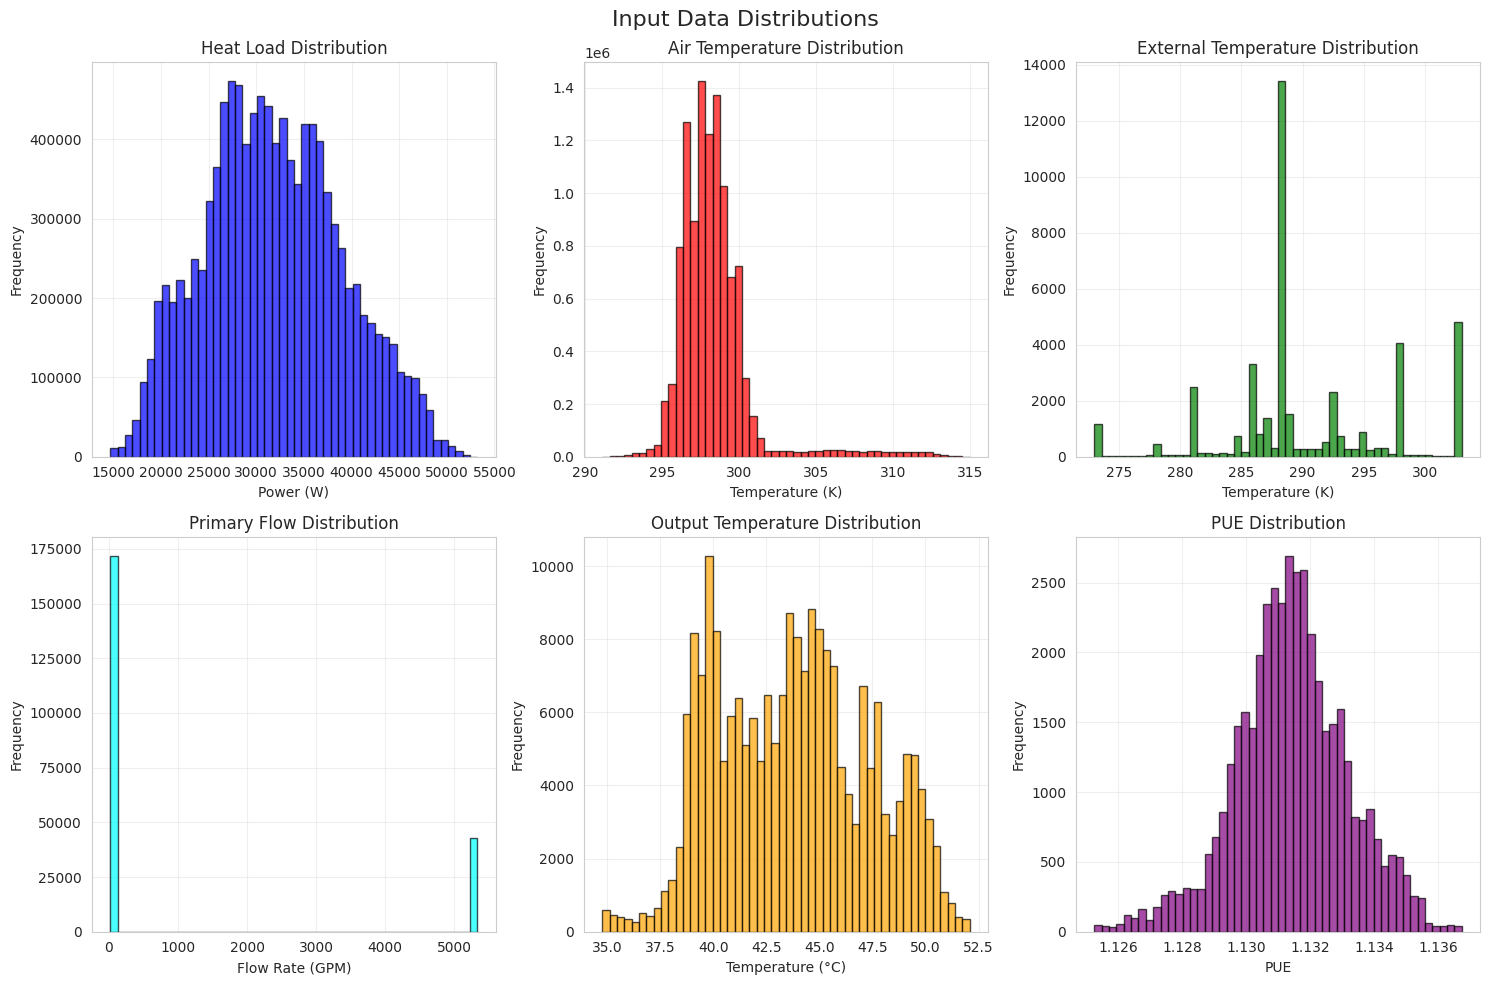

✓ Saved to ../results/summit/systematic/data_processing_tests/data_distributions.png


In [7]:
# Visualize Data Distributions
print("="*80)
print("DATA DISTRIBUTION VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Input Data Distributions', fontsize=16)

# Power distribution
ax = axes[0, 0]
power_data = df[power_cols].values.flatten()
ax.hist(power_data, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.set_xlabel('Power (W)')
ax.set_ylabel('Frequency')
ax.set_title('Heat Load Distribution')
ax.grid(True, alpha=0.3)

# Air temperature distribution
ax = axes[0, 1]
air_temp_data = df[air_temp_cols].values.flatten()
ax.hist(air_temp_data, bins=50, alpha=0.7, color='red', edgecolor='black')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Frequency')
ax.set_title('Air Temperature Distribution')
ax.grid(True, alpha=0.3)

# External temperature distribution
ax = axes[0, 2]
if ext_temp_col:
    ext_temp_data = df[ext_temp_col[0]].values
    ax.hist(ext_temp_data, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Frequency')
    ax.set_title('External Temperature Distribution')
    ax.grid(True, alpha=0.3)

# Flow rate distribution
ax = axes[1, 0]
if prim_flow_cols:
    flow_data = df[prim_flow_cols].values.flatten()
    ax.hist(flow_data, bins=50, alpha=0.7, color='cyan', edgecolor='black')
    ax.set_xlabel('Flow Rate (GPM)')
    ax.set_ylabel('Frequency')
    ax.set_title('Primary Flow Distribution')
    ax.grid(True, alpha=0.3)

# Temperature output distribution
ax = axes[1, 1]
if temp_output_cols:
    temp_out_data = df[temp_output_cols].values.flatten()
    ax.hist(temp_out_data, bins=50, alpha=0.7, color='orange', edgecolor='black')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Frequency')
    ax.set_title('Output Temperature Distribution')
    ax.grid(True, alpha=0.3)

# PUE distribution
ax = axes[1, 2]
if 'pue' in df.columns:
    ax.hist(df['pue'].values, bins=50, alpha=0.7, color='purple', edgecolor='black')
    ax.set_xlabel('PUE')
    ax.set_ylabel('Frequency')
    ax.set_title('PUE Distribution')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/data_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {OUTPUT_DIR}/data_distributions.png")

In [10]:
#  Data Validation - Initialize
print("="*80)
print("DATA VALIDATION")
print("="*80)

validator = DataValidator(config=config, strict=False)
print("✓ Validator initialized")

2026-01-25 01:49:51 - fmu2ml.data.processors.data_validator - INFO - Data validator initialized for datacenter cooling system


DATA VALIDATION
✓ Validator initialized


In [11]:
# Validate Input Data
print("\n" + "="*80)
print("VALIDATING INPUT DATA")
print("="*80)

# Create input DataFrame
input_data = df[input_cols].copy()

# Add time if exists
if 'time' in df.columns:
    input_data['time'] = df['time']

# Validate
input_validation_results = validator.validate(input_data, data_type='input')

# Display summary
input_summary = validator.get_summary_report(input_validation_results)

display(Markdown("### Input Validation Summary"))
print(f"Total checks: {input_summary['total_checks']}")
print(f"Errors: {input_summary['errors']}")
print(f"Warnings: {input_summary['warnings']}")
print(f"Info: {input_summary['infos']}")

# Display errors
if input_summary['error_details']:
    display(Markdown("#### Errors"))
    for error in input_summary['error_details'][:10]:
        print(f"  - {error['message']}")
        if error['column']:
            print(f"    Column: {error['column']}")
        if error['count']:
            print(f"    Count: {error['count']}")

# Display warnings
if input_summary['warning_details']:
    display(Markdown("#### Warnings"))
    for warning in input_summary['warning_details'][:10]:
        print(f"  - {warning['message']}")
        if warning['column']:
            print(f"    Column: {warning['column']}")
        if warning['count']:
            print(f"    Count: {warning['count']}")

2026-01-25 01:49:53 - fmu2ml.data.processors.data_validator - INFO - Validating input data: 42922 samples, 516 columns



VALIDATING INPUT DATA


2026-01-25 01:49:56 - fmu2ml.data.processors.data_validator - INFO - Validation complete: 345 errors, 188 warnings, 1 info
2026-01-25 01:49:56 - fmu2ml.data.processors.data_validator - ERROR - Validation errors:
2026-01-25 01:49:56 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (50000.00) [simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total] (count: 623)
2026-01-25 01:49:56 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (50000.00) [simulator_1_datacenter_1_computeBlock_14_cabinet_1_sources_Q_flow_total] (count: 1042)
2026-01-25 01:49:56 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (50000.00) [simulator_1_datacenter_1_computeBlock_21_cabinet_1_sources_Q_flow_total] (count: 278)
2026-01-25 01:49:56 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (50000.00) [simulator_1_datacenter_1_computeBlock_22_cabinet_1_sources_Q_flow_total] (count: 622)
2026-01-25 01:49

### Input Validation Summary

Total checks: 534
Errors: 345
Warnings: 188
Info: 1


#### Errors

  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total
    Count: 623
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_14_cabinet_1_sources_Q_flow_total
    Count: 1042
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_21_cabinet_1_sources_Q_flow_total
    Count: 278
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_22_cabinet_1_sources_Q_flow_total
    Count: 622
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_28_cabinet_1_sources_Q_flow_total
    Count: 556
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_29_cabinet_1_sources_Q_flow_total
    Count: 459
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_30_cabinet_1_sources_Q_flow_total
    Count: 276
  - Values above maximum (50000.00)
    Column: simulat

#### Warnings

  - Outliers detected (0.71%)
    Column: simulator_1_datacenter_1_computeBlock_55_cabinet_1_sources_Q_flow_total
    Count: 305
  - Outliers detected (1.15%)
    Column: simulator_1_datacenter_1_computeBlock_97_cabinet_1_sources_Q_flow_total
    Count: 494
  - Outliers detected (0.66%)
    Column: simulator_1_datacenter_1_computeBlock_121_cabinet_1_sources_Q_flow_total
    Count: 283
  - Outliers detected (1.34%)
    Column: simulator_1_datacenter_1_computeBlock_162_cabinet_1_sources_Q_flow_total
    Count: 574
  - Outliers detected (4.32%)
    Column: simulator_1_datacenter_1_computeBlock_167_cabinet_1_sources_Q_flow_total
    Count: 1855
  - Outliers detected (0.65%)
    Column: simulator_1_datacenter_1_computeBlock_234_cabinet_1_sources_Q_flow_total
    Count: 280
  - Outliers detected (2.33%)
    Column: simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_T_Air
    Count: 1000
  - Outliers detected (2.97%)
    Column: simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources

In [12]:
# Validate Output Data
print("\n" + "="*80)
print("VALIDATING OUTPUT DATA")
print("="*80)

# Create output DataFrame
output_data = df[output_cols].copy()

# Add time if exists
if 'time' in df.columns:
    output_data['time'] = df['time']

# Validate
output_validation_results = validator.validate(output_data, data_type='output')

# Display summary
output_summary = validator.get_summary_report(output_validation_results)

display(Markdown("### Output Validation Summary"))
print(f"Total checks: {output_summary['total_checks']}")
print(f"Errors: {output_summary['errors']}")
print(f"Warnings: {output_summary['warnings']}")
print(f"Info: {output_summary['infos']}")

# Display errors
if output_summary['error_details']:
    display(Markdown("#### Errors"))
    for error in output_summary['error_details'][:10]:
        print(f"  - {error['message']}")
        if error['column']:
            print(f"    Column: {error['column']}")
        if error['count']:
            print(f"    Count: {error['count']}")

# Display warnings
if output_summary['warning_details']:
    display(Markdown("#### Warnings"))
    for warning in output_summary['warning_details'][:10]:
        print(f"  - {warning['message']}")
        if warning['column']:
            print(f"    Column: {warning['column']}")
        if warning['count']:
            print(f"    Count: {warning['count']}")


VALIDATING OUTPUT DATA


2026-01-25 01:50:09 - fmu2ml.data.processors.data_validator - INFO - Validating output data: 42922 samples, 5915 columns
2026-01-25 01:50:35 - fmu2ml.data.processors.data_validator - INFO - Validation complete: 1028 errors, 751 warnings, 1 info
2026-01-25 01:50:35 - fmu2ml.data.processors.data_validator - ERROR - Validation errors:
2026-01-25 01:50:35 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (25.00) [simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C] (count: 42922)
2026-01-25 01:50:35 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (40.00) [simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_r_C] (count: 42922)
2026-01-25 01:50:35 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (25.00) [simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_sec_s_C] (count: 42922)
2026-01-25 01:50:35 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (40.0

### Output Validation Summary

Total checks: 1780
Errors: 1028
Warnings: 751
Info: 1


#### Errors

  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C
    Count: 42922
  - Values above maximum (40.00)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_r_C
    Count: 42922
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_sec_s_C
    Count: 42922
  - Values above maximum (40.00)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_sec_r_C
    Count: 42922
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_s_C
    Count: 42922
  - Values above maximum (40.00)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_r_C
    Count: 42922
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_sec_s_C
    Count: 42922
  - Values above maximum (40.00)
    Column: simulator[1].datacenter[1].computeBlock[2

#### Warnings

  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_sec
    Count: 4
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_sec_GPM
    Count: 4
  - Outliers detected (0.04%)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.m_flow_sec
    Count: 19
  - Outliers detected (0.04%)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.V_flow_sec_GPM
    Count: 19
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.m_flow_sec
    Count: 5
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.V_flow_sec_GPM
    Count: 5
  - Outliers detected (0.02%)
    Column: simulator[1].datacenter[1].computeBlock[4].cdu[1].summary.m_flow_sec
    Count: 7
  - Outliers detected (0.02%)
    Column: simulator[1].datacenter[1].computeBlock[4].cdu[1].summary.V_flow_sec_GPM
   

In [13]:
# Normalization - Initialize and Compute Stats
print("="*80)
print("NORMALIZATION")
print("="*80)

# Initialize normalization handler
norm_handler = NormalizationHandler()

# Compute statistics
print("Computing normalization statistics...")
mean_in, std_in, mean_out, std_out = norm_handler.compute_stats(
    df, input_cols, output_cols
)

print(f"✓ Statistics computed")
print(f"  Input features: {len(mean_in)}")
print(f"  Output features: {len(mean_out)}")

# Display sample statistics
display(Markdown("### Input Normalization Statistics"))
print(f"Mean range: [{mean_in.min():.2f}, {mean_in.max():.2f}]")
print(f"Std range: [{std_in.min():.2f}, {std_in.max():.2f}]")

display(Markdown("### Output Normalization Statistics"))
print(f"Mean range: [{mean_out.min():.2f}, {mean_out.max():.2f}]")
print(f"Std range: [{std_out.min():.2f}, {std_out.max():.2f}]")

NORMALIZATION
Computing normalization statistics...
✓ Statistics computed
  Input features: 515
  Output features: 5914


### Input Normalization Statistics

Mean range: [290.25, 35379.13]
Std range: [1.10, 8828.27]


### Output Normalization Statistics

Mean range: [0.70, 539512.25]
Std range: [0.00, 6105.66]


In [14]:
# Test Normalization
print("\n" + "="*80)
print("TESTING NORMALIZATION")
print("="*80)

# Sample data
sample_idx = 100
sample_input = df[input_cols].iloc[sample_idx].values
sample_output = df[output_cols].iloc[sample_idx].values

print("Original values:")
print(f"  Input sample: {sample_input[:5]}")
print(f"  Output sample: {sample_output[:5]}")

# Normalize
normalized_input = norm_handler.normalize_input(sample_input)
normalized_output = norm_handler.normalize_output(sample_output)

print("\nNormalized values:")
print(f"  Input sample: {normalized_input[:5]}")
print(f"  Output sample: {normalized_output[:5]}")

# Denormalize
denorm_input = norm_handler.denormalize_input(normalized_input)
denorm_output = norm_handler.denormalize_output(normalized_output)

print("\nDenormalized values:")
print(f"  Input sample: {denorm_input[:5]}")
print(f"  Output sample: {denorm_output[:5]}")

# Verify reconstruction
input_error = np.abs(sample_input - denorm_input).max()
output_error = np.abs(sample_output - denorm_output).max()

print(f"\nReconstruction error:")
print(f"  Input max error: {input_error:.6e}")
print(f"  Output max error: {output_error:.6e}")

if input_error < 1e-6 and output_error < 1e-6:
    print("✓ Normalization/denormalization working correctly")
else:
    print("⚠ Large reconstruction error detected!")


TESTING NORMALIZATION
Original values:
  Input sample: [22185.78375326 41744.77025252 38352.34383133 29440.70443688
 20714.36262011]
  Output sample: [3.32175170e+02 5.27262175e+03 1.29261140e+00 2.05176413e+01
 2.00000968e+01]

Normalized values:
  Input sample: [-1.43145728  1.65592452  0.82074802  0.07571246 -1.32367542]
  Output sample: [-1.93543195 -1.93543303 -1.88888186 -1.88888119  0.67694793]

Denormalized values:
  Input sample: [22185.78375326 41744.77025252 38352.34383133 29440.70443688
 20714.36262011]
  Output sample: [3.32175170e+02 5.27262175e+03 1.29261140e+00 2.05176413e+01
 2.00000968e+01]

Reconstruction error:
  Input max error: 0.000000e+00
  Output max error: 0.000000e+00
✓ Normalization/denormalization working correctly


In [15]:
# Save Normalization Statistics
print("\n" + "="*80)
print("SAVING NORMALIZATION STATISTICS")
print("="*80)

stats_path = f"{OUTPUT_DIR}/normalization_stats.npz"
norm_handler.save_stats(stats_path)

print(f"✓ Statistics saved to {stats_path}")
print(f"✓ JSON version saved to {stats_path.replace('.npz', '.json')}")

# Verify loading
norm_handler_loaded = NormalizationHandler(stats_path)
print("✓ Successfully loaded statistics from file")

# Verify loaded stats match
assert np.allclose(norm_handler.mean_in, norm_handler_loaded.mean_in)
assert np.allclose(norm_handler.std_in, norm_handler_loaded.std_in)
print("✓ Loaded statistics match original")


SAVING NORMALIZATION STATISTICS
✓ Statistics saved to ../results/summit/systematic/data_processing_tests/normalization_stats.npz
✓ JSON version saved to ../results/summit/systematic/data_processing_tests/normalization_stats.json
✓ Successfully loaded statistics from file
✓ Loaded statistics match original


In [20]:
# Create Dataset
print("="*80)
print("CREATING PYTORCH DATASET")
print("="*80)

dataset = DatacenterCoolingDataset(
    data_path=DATA_PATH,
    chunk_indices=[CHUNK_TO_TEST],
    sequence_length=SEQUENCE_LENGTH,
    stride=1,
    normalize=True,
    config=config
)

print(f"Dataset size: {len(dataset)} sequences")
print(f"Sequence length: {SEQUENCE_LENGTH}")
print(f"Input features: {len(dataset.input_cols)}")
print(f"Output features: {len(dataset.output_cols)}")

CREATING PYTORCH DATASET


TypeError: 'NoneType' object is not iterable

In [ ]:
# Test Dataset Indexing
print("\n" + "="*80)
print("TESTING DATASET INDEXING")
print("="*80)

# Get a sample
sample_idx = 0
inputs, outputs = dataset[sample_idx]

print(f"Sample {sample_idx}:")
print(f"  Input shape: {inputs.shape}")
print(f"  Output shape: {outputs.shape}")
print(f"  Input dtype: {inputs.dtype}")
print(f"  Output dtype: {outputs.dtype}")

# Check normalization
print(f"\nInput statistics:")
print(f"  Mean: {inputs.mean():.4f}")
print(f"  Std: {inputs.std():.4f}")
print(f"  Min: {inputs.min():.4f}")
print(f"  Max: {inputs.max():.4f}")

print(f"\nOutput statistics:")
print(f"  Mean: {outputs.mean():.4f}")
print(f"  Std: {outputs.std():.4f}")
print(f"  Min: {outputs.min():.4f}")
print(f"  Max: {outputs.max():.4f}")

# Visualize first sequence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(inputs[:, 0].numpy(), marker='o', label='Feature 1')
ax.plot(inputs[:, 1].numpy(), marker='s', label='Feature 2')
ax.set_xlabel('Timestep')
ax.set_ylabel('Normalized Value')
ax.set_title('Input Sequence (first 2 features)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(range(min(20, len(outputs))), outputs[:20].numpy())
ax.set_xlabel('Output Feature')
ax.set_ylabel('Normalized Value')
ax.set_title('Output Values (first 20 features)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_sequence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {OUTPUT_DIR}/sample_sequence.png")

In [19]:
# Create DataLoader
print("="*80)
print("CREATING DATALOADER")
print("="*80)

from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Use 0 for notebook
    pin_memory=True,
    
)

print(f"DataLoader created:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Number of batches: {len(dataloader)}")
print(f"  Total samples: {len(dataset)}")

CREATING DATALOADER


NameError: name 'dataset' is not defined

In [ ]:
# Test DataLoader Iteration
print("\n" + "="*80)
print("TESTING DATALOADER ITERATION")
print("="*80)

# Get first batch
batch_inputs, batch_outputs = next(iter(dataloader))

print(f"Batch shapes:")
print(f"  Inputs: {batch_inputs.shape}")  # [batch, seq_len, features]
print(f"  Outputs: {batch_outputs.shape}")  # [batch, features]

print(f"\nBatch statistics:")
print(f"  Input mean: {batch_inputs.mean():.4f}")
print(f"  Input std: {batch_inputs.std():.4f}")
print(f"  Output mean: {batch_outputs.mean():.4f}")
print(f"  Output std: {batch_outputs.std():.4f}")

# Visualize batch
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for i in range(min(10, BATCH_SIZE)):
    ax.plot(batch_inputs[i, :, 0].numpy(), alpha=0.6, linewidth=0.8)
ax.set_xlabel('Timestep')
ax.set_ylabel('Normalized Value')
ax.set_title(f'Input Sequences (Feature 0, first 10 samples)')
ax.grid(True, alpha=0.3)

ax = axes[1]
feature_idx = 0
ax.hist(batch_outputs[:, feature_idx].numpy(), bins=30, alpha=0.7, edgecolor='black')
ax.set_xlabel('Normalized Value')
ax.set_ylabel('Frequency')
ax.set_title(f'Output Distribution (Feature {feature_idx})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/batch_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {OUTPUT_DIR}/batch_visualization.png")

In [17]:
# Physics Validation - Initialize
print("="*80)
print("PHYSICS VALIDATION")
print("="*80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

physics_validator = PhysicsValidator(
    config=config,
    device=device,
    system_name=SYSTEM_NAME
)

print("✓ Physics validator initialized")
print(f"  Number of CDUs: {physics_validator.num_cdus}")
print(f"  Physics constraints loaded")

2026-01-25 01:52:29 - fmu2ml.data.processors.physics_loss - INFO - Physics validator initialized for 257 CDUs


PHYSICS VALIDATION
Using device: cuda
✓ Physics validator initialized
  Number of CDUs: 257
  Physics constraints loaded


In [18]:
# Test Physics Validation on Sample Batch
print("\n" + "="*80)
print("TESTING PHYSICS VALIDATION ON SAMPLE BATCH")
print("="*80)

# Get a batch
batch_inputs, batch_outputs = next(iter(dataloader))

# Move to device
batch_inputs = batch_inputs.to(device)
batch_outputs = batch_outputs.to(device)

print(f"Batch size: {batch_inputs.shape[0]}")

# Denormalize for physics validation
denorm_inputs = torch.tensor(
    dataset.norm_handler.denormalize_input(batch_inputs.cpu().numpy()),
    device=device
)
denorm_outputs = torch.tensor(
    dataset.norm_handler.denormalize_output(batch_outputs.cpu().numpy()),
    device=device
)

print("✓ Data denormalized for physics validation")

# Compute physics loss
physics_losses = physics_validator.compute_physics_loss(denorm_outputs, denorm_inputs)

display(Markdown("### Physics Loss Components"))
for key, value in physics_losses.items():
    print(f"  {key.replace('_', ' ').title()}: {value:.6f}")


TESTING PHYSICS VALIDATION ON SAMPLE BATCH


NameError: name 'dataloader' is not defined

In [ ]:
#  Detailed Physics Violation Analysis
print("\n" + "="*80)
print("DETAILED PHYSICS VIOLATION ANALYSIS")
print("="*80)

# Analyze violations
analysis = physics_validator.analyze_physics_violations(denorm_outputs, denorm_inputs)

display(Markdown("### Temperature Ordering Analysis"))
temp_analysis = analysis['temp_ordering']
print(f"Primary violations: {temp_analysis['primary_violations'].sum()}")
print(f"Secondary violations: {temp_analysis['secondary_violations'].sum()}")
print(f"Cooling tower violations: {temp_analysis['cooling_tower_violations'].sum()}")
print(f"Total violation rate: {temp_analysis['total_violation_rate']:.4%}")

display(Markdown("### Approach Temperature Analysis"))
approach_analysis = analysis['approach_temp']
print(f"Approach 1 violations: {approach_analysis['approach1_violations'].sum()}")
print(f"Approach 2 violations: {approach_analysis['approach2_violations'].sum()}")
print(f"Violation rate: {approach_analysis['violation_rate']:.4%}")

display(Markdown("### PUE Analysis"))
pue_analysis = analysis['pue']
print(f"Actual PUE range: [{pue_analysis['actual_pue'].min():.3f}, {pue_analysis['actual_pue'].max():.3f}]")
print(f"Expected PUE range: [{pue_analysis['expected_pue'].min():.3f}, {pue_analysis['expected_pue'].max():.3f}]")
print(f"Mean PUE error: {pue_analysis['pue_error'].mean():.4f}")
print(f"Below 1.0 violations: {pue_analysis['below_1_violations']:.4%}")

display(Markdown("### Mass Conservation Analysis"))
mass_analysis = analysis['mass_conservation']
print(f"Total CDU flow range: [{mass_analysis['total_cdu_flow'].min():.2f}, {mass_analysis['total_cdu_flow'].max():.2f}] GPM")
print(f"Datacenter flow range: [{mass_analysis['datacenter_flow'].min():.2f}, {mass_analysis['datacenter_flow'].max():.2f}] GPM")
print(f"Mean relative error: {mass_analysis['relative_error'].mean():.4%}")

display(Markdown("### Energy Balance Analysis"))
energy_analysis = analysis['energy_balance']
print(f"Mean error: {energy_analysis['mean_error']:.4f}")
print(f"Max error: {energy_analysis['max_error']:.4f}")
print(f"Violation rate (>10%): {energy_analysis['violation_rate']:.4%}")

In [ ]:
# Visualize Physics Violations
print("\n" + "="*80)
print("VISUALIZING PHYSICS VIOLATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Physics Violation Analysis', fontsize=16)

# Temperature violations
ax = axes[0, 0]
violations = [
    temp_analysis['primary_violations'].sum(),
    temp_analysis['secondary_violations'].sum(),
    temp_analysis['cooling_tower_violations'].sum()
]
ax.bar(['Primary', 'Secondary', 'Cooling Tower'], violations, color=['red', 'orange', 'yellow'])
ax.set_ylabel('Number of Violations')
ax.set_title('Temperature Ordering Violations')
ax.grid(True, alpha=0.3, axis='y')

# Approach temperature distributions
ax = axes[0, 1]
ax.hist(approach_analysis['approach1_temps'].flatten(), bins=30, alpha=0.6, label='Approach 1', color='blue')
ax.hist(approach_analysis['approach2_temps'].flatten(), bins=30, alpha=0.6, label='Approach 2', color='green')
ax.axvline(2.0, color='red', linestyle='--', label='Min Threshold')
ax.set_xlabel('Temperature Difference (°C)')
ax.set_ylabel('Frequency')
ax.set_title('Approach Temperature Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# PUE comparison
ax = axes[0, 2]
ax.scatter(pue_analysis['expected_pue'], pue_analysis['actual_pue'], alpha=0.5, s=10)
ax.plot([1.0, 2.5], [1.0, 2.5], 'r--', label='Perfect Match')
ax.set_xlabel('Expected PUE')
ax.set_ylabel('Actual PUE')
ax.set_title('PUE: Expected vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)

# Flow conservation
ax = axes[1, 0]
ax.scatter(mass_analysis['datacenter_flow'], mass_analysis['total_cdu_flow'], alpha=0.5, s=10)
ax.plot([0, mass_analysis['datacenter_flow'].max()], 
        [0, mass_analysis['datacenter_flow'].max()], 'r--', label='Perfect Match')
ax.set_xlabel('Datacenter Flow (GPM)')
ax.set_ylabel('Sum of CDU Flows (GPM)')
ax.set_title('Mass Conservation Check')
ax.legend()
ax.grid(True, alpha=0.3)

# Relative flow error
ax = axes[1, 1]
ax.hist(mass_analysis['relative_error'] * 100, bins=30, alpha=0.7, color='purple', edgecolor='black')
ax.set_xlabel('Relative Error (%)')
ax.set_ylabel('Frequency')
ax.set_title('Flow Conservation Error Distribution')
ax.grid(True, alpha=0.3)

# Physics loss components
ax = axes[1, 2]
loss_components = {k: v for k, v in physics_losses.items() if k != 'total'}
ax.bar(range(len(loss_components)), list(loss_components.values()), 
       tick_label=[k.replace('_', '\n') for k in loss_components.keys()], color='steelblue')
ax.set_ylabel('Loss Value')
ax.set_title('Physics Loss Components')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/physics_violations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {OUTPUT_DIR}/physics_violations.png")

In [ ]:
#  Validate Multiple Batches
print("="*80)
print("VALIDATING MULTIPLE BATCHES")
print("="*80)

num_batches_to_test = min(10, len(dataloader))
all_physics_losses = []

print(f"Testing {num_batches_to_test} batches...")

for i, (inputs, outputs) in enumerate(dataloader):
    if i >= num_batches_to_test:
        break
    
    # Denormalize
    denorm_inputs = torch.tensor(
        dataset.norm_handler.denormalize_input(inputs.numpy()),
        device=device
    )
    denorm_outputs = torch.tensor(
        dataset.norm_handler.denormalize_output(outputs.numpy()),
        device=device
    )
    
    # Compute physics losses
    losses = physics_validator.compute_physics_loss(denorm_outputs, denorm_inputs)
    all_physics_losses.append(losses)
    
    if (i + 1) % 5 == 0:
        print(f"  Processed {i+1}/{num_batches_to_test} batches")

print(f"✓ Validated {len(all_physics_losses)} batches")

# Aggregate results
loss_df = pd.DataFrame(all_physics_losses)

display(Markdown("### Aggregated Physics Loss Statistics"))
display(loss_df.describe())

# Visualize loss trends
fig, ax = plt.subplots(figsize=(12, 6))

for column in loss_df.columns:
    if column != 'total':
        ax.plot(loss_df[column], marker='o', label=column.replace('_', ' ').title(), alpha=0.7)

ax.set_xlabel('Batch Index')
ax.set_ylabel('Loss Value')
ax.set_title('Physics Loss Components Across Batches')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/multi_batch_physics_losses.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {OUTPUT_DIR}/multi_batch_physics_losses.png")

In [ ]:
# Cleanup
print("="*80)
print("CLEANUP")
print("="*80)

# Close any open figures
plt.close('all')

print("✓ All tests complete!")
print(f"✓ Results saved to {OUTPUT_DIR}")